# Model Diagnostics and Feature Engineering

Compare the tuned ensemble with a small engineered feature set, analyze its errors,
and measure feature importance. Run the notebook from top to bottom.

**Note:** the holdout was already used during model exploration. Treat it as validation
data and create a new untouched test set before final reporting.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


def find_project_root():
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (path / "data" / "raw" / "cars.csv").exists():
            return path
    raise FileNotFoundError("Could not find data/raw/cars.csv")


CSV_PATH = find_project_root() / "data" / "raw" / "cars.csv"
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print(CSV_PATH)

C:\Users\tuomas.kuusisto_cens\projects\car-price-prediction\data\raw\cars.csv


## 1. Data and features

The engineered set adds usage intensity, mechanical ratios, equipment level, body type,
model version, and original market. Price-derived columns are excluded to avoid target leakage.


In [2]:
BASE_NUM = [
    "mileage_km_raw", "vehicle_age", "nr_seats", "nr_doors", "power_hp",
    "gears", "cylinders", "cylinders_volume_cc", "weight_kg_numeric",
    "electric_range_km", "fuel_cons_comb_l100_km", "co2_emission_grper_km",
    "nr_prev_owners",
]
BASE_CAT = [
    "make", "model", "paint_type", "transmission", "drive_train",
    "fuel_category", "primary_fuel", "is_used", "is_new", "had_accident",
    "has_full_service_history", "is_rental", "envir_standard", "offer_type",
    "country_code", "seller_is_dealer", "seller_type",
]
EQUIPMENT = [
    "equipment_comfort", "equipment_entertainment", "equipment_extra", "equipment_safety"
]
EXTRA_RAW = [
    "model_version", "body_type", "original_market", *EQUIPMENT
]

usecols = sorted(set([
    "id", "price", "registration_date", "weight_kg",
    *[c for c in BASE_NUM if c not in {"vehicle_age", "weight_kg_numeric"}],
    *BASE_CAT, *EXTRA_RAW,
]))
df = pd.read_csv(CSV_PATH, usecols=usecols, low_memory=False)

registration = pd.to_datetime(df["registration_date"], errors="coerce")
today = pd.Timestamp.today()
df["vehicle_age_months"] = (
    (today.year - registration.dt.year) * 12 + today.month - registration.dt.month
).astype(float)
df.loc[~df["vehicle_age_months"].between(0, 960), "vehicle_age_months"] = np.nan
df["vehicle_age"] = df["vehicle_age_months"] / 12
df["weight_kg_numeric"] = pd.to_numeric(
    df["weight_kg"].astype("string").str.extract(r"([\d,.]+)", expand=False)
    .str.replace(",", "", regex=False),
    errors="coerce",
)

def equipment_count(series):
    text = series.fillna("").astype(str).str.strip()
    return (text.str.count(r"', '") + 1).where(text.str.len() > 2, 0)


df["equipment_count"] = sum(equipment_count(df[c]) for c in EQUIPMENT)
df["log_mileage"] = np.log1p(df["mileage_km_raw"])
df["mileage_per_year"] = df["mileage_km_raw"] / df["vehicle_age"].clip(lower=0.5)
df["engine_liters"] = df["cylinders_volume_cc"] / 1_000
df["power_to_weight"] = df["power_hp"] / df["weight_kg_numeric"] * 1_000

ENGINEERED_NUM = BASE_NUM + [
    "vehicle_age_months", "log_mileage", "mileage_per_year",
    "engine_liters", "power_to_weight", "equipment_count",
]
ENGINEERED_CAT = BASE_CAT + [
    "model_version", "body_type", "original_market"
]

df = df.loc[
    df["price"].between(1_000, 1_000_000) & df["country_code"].notna()
].drop_duplicates("id")

train_idx, test_idx = train_test_split(
    df.index, test_size=0.20, random_state=RANDOM_STATE,
    stratify=df["country_code"],
)
y_train = df.loc[train_idx, "price"].astype(float)
y_test = df.loc[test_idx, "price"].astype(float)

print(f"Rows: {len(df):,}")
print(f"Train: {len(train_idx):,} | validation: {len(test_idx):,}")

Rows: 118,045
Train: 94,436 | validation: 23,609


## 2. Baseline versus engineered features

Both ensembles use the same rows and the tuned parameters from the previous notebook.

In [3]:
def prepare(numeric, categorical):
    transformer = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1,
                min_frequency=20, max_categories=300,
            )),
        ]), categorical),
    ], verbose_feature_names_out=False)

    columns = numeric + categorical
    train_values = transformer.fit_transform(df.loc[train_idx, columns])
    test_values = transformer.transform(df.loc[test_idx, columns])
    output_columns = transformer.get_feature_names_out().tolist()

    X_train = pd.DataFrame(train_values, columns=output_columns, index=train_idx)
    X_test = pd.DataFrame(test_values, columns=output_columns, index=test_idx)
    return X_train, X_test, output_columns


def tuned_models():
    base_models = {
        "Extra Trees": ExtraTreesRegressor(
            n_estimators=140, max_features=1.0, n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestRegressor(
            n_estimators=140, max_features=0.5, n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "XGBoost": XGBRegressor(
            n_estimators=700, learning_rate=0.03, max_depth=10,
            subsample=0.75, objective="reg:squarederror", n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    }
    return {
        name: TransformedTargetRegressor(
            regressor=model, func=np.log1p, inverse_func=np.expm1,
            check_inverse=False,
        )
        for name, model in base_models.items()
    }


def fit_feature_set(label, numeric, categorical):
    X_train, X_test, features = prepare(numeric, categorical)
    models = tuned_models()
    predictions = []
    started = perf_counter()

    for i, (name, model) in enumerate(models.items(), 1):
        print(f"[{label} {i}/3] {name}", flush=True)
        model.fit(X_train, y_train)
        predictions.append(model.predict(X_test))

    prediction = np.clip(np.mean(predictions, axis=0), 1_000, 1_000_000)
    print(f"Finished in {perf_counter() - started:.1f}s\n")
    return models, X_test, features, prediction


baseline = fit_feature_set("Baseline", BASE_NUM, BASE_CAT)
engineered = fit_feature_set("Engineered", ENGINEERED_NUM, ENGINEERED_CAT)

def score(name, result):
    prediction = result[3]
    germany = df.loc[test_idx, "country_code"].eq("DE").to_numpy()
    return {
        "feature_set": name,
        "MAE": mean_absolute_error(y_test, prediction),
        "Germany_MAE": mean_absolute_error(y_test.to_numpy()[germany], prediction[germany]),
        "within_20_percent": np.mean(
            np.abs(prediction - y_test.to_numpy()) / y_test.to_numpy() <= 0.20
        ),
    }


comparison = pd.DataFrame([
    score("Baseline", baseline), score("Engineered", engineered)
]).sort_values("MAE").reset_index(drop=True)
display(comparison.style.format({
    "MAE": "EUR {:,.0f}", "Germany_MAE": "EUR {:,.0f}",
    "within_20_percent": "{:.1%}",
}))

selected_name = comparison.loc[0, "feature_set"]
selected = engineered if selected_name == "Engineered" else baseline
models, X_test, features, prediction = selected
print(f"Selected for diagnostics: {selected_name}")

[Baseline 1/3] Extra Trees
[Baseline 2/3] Random Forest
[Baseline 3/3] XGBoost
Finished in 43.9s

[Engineered 1/3] Extra Trees
[Engineered 2/3] Random Forest
[Engineered 3/3] XGBoost
Finished in 74.6s



,feature_set,MAE,Germany_MAE,within_20_percent
0,Baseline,"EUR 4,591","EUR 4,560",90.6%
1,Engineered,"EUR 4,664","EUR 4,713",90.2%


Selected for diagnostics: Baseline


## 3. Error analysis

Positive residuals are overpredictions and negative residuals are underpredictions.

,value
MAE,4591.301643
Median absolute error,2190.161580
Median percentage error,0.058124
Mean bias,-770.522273


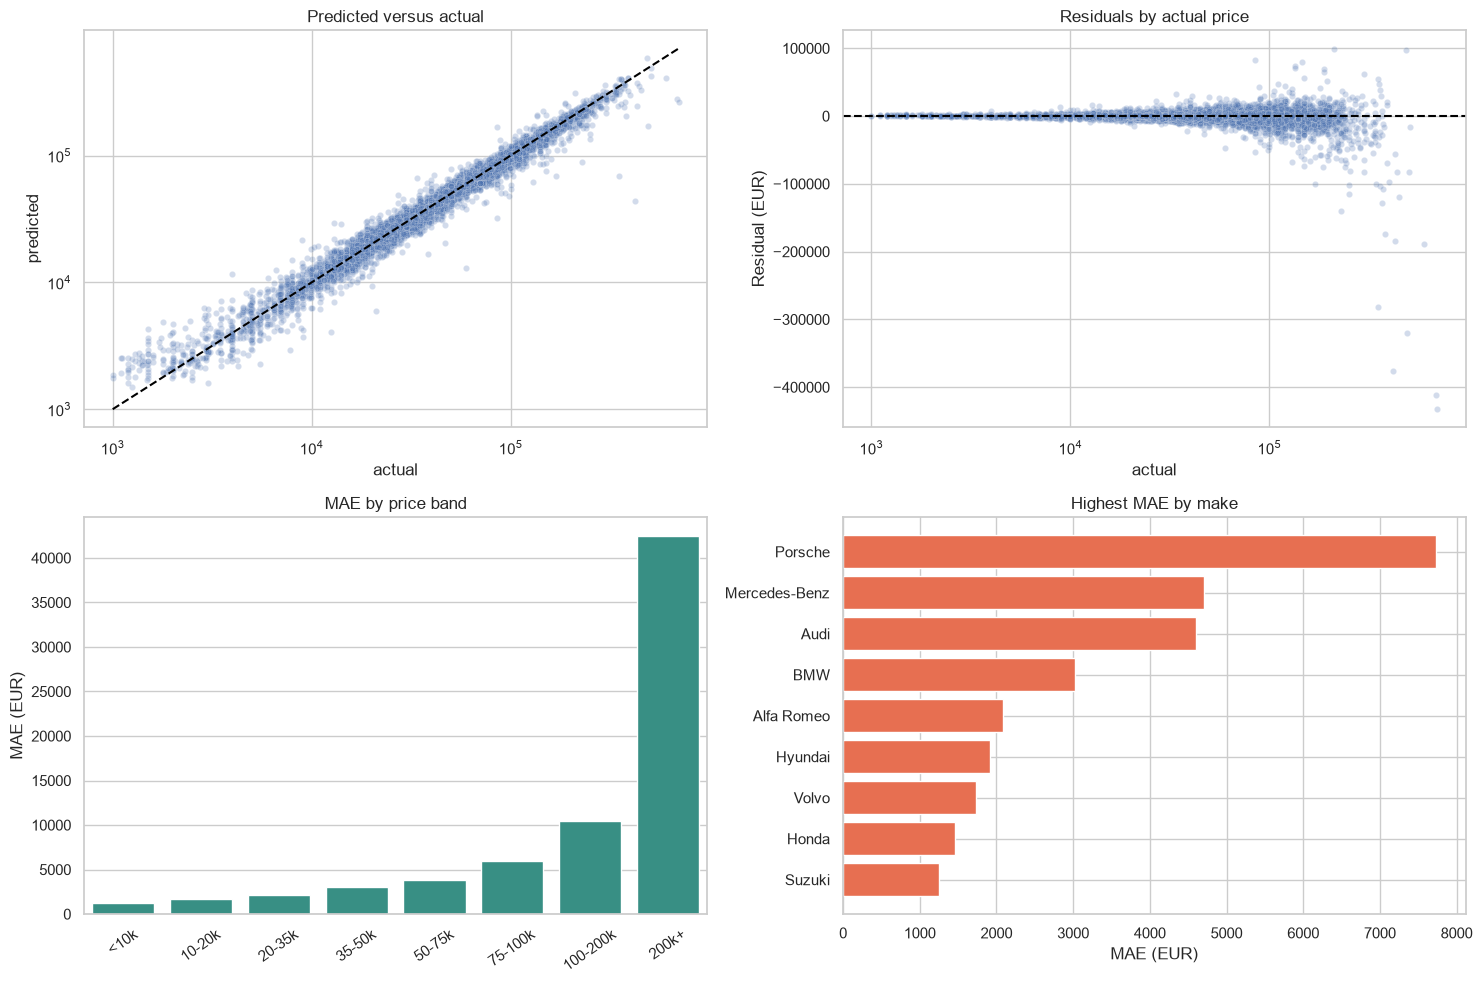

Country errors


,rows,MAE,median_APE,bias
country_code,,,,
LU,157,6918.10,0.06,1105.25
FR,1228,6566.47,0.06,-1907.17
AT,1438,5486.89,0.07,-2365.41
ES,1602,5182.18,0.05,-1945.08
DE,9093,4560.07,0.05,-397.16
NL,3396,4523.04,0.06,-1160.20
BE,1914,4127.83,0.06,-393.53
IT,4781,3833.65,0.06,-251.14


Model errors


,rows,MAE,median_APE,bias
model,,,,
RS6,90,13063.52,0.06,-1125.99
992,652,12801.16,0.05,74.99
911,502,11925.56,0.06,-2105.18
991,292,11371.70,0.05,-1005.26
996,120,10668.67,0.11,-2677.11
997,183,8785.68,0.07,1442.58
A 180,139,8638.41,0.04,-6820.42
M3,94,8002.99,0.07,-4042.08
M5,88,7564.06,0.06,1065.80


Largest individual errors


,id,make,model,country_code,vehicle_age,mileage_km_raw,actual,predicted,residual,absolute_error,absolute_percentage_error,price_band
85856,b901fe72-1c6e-408f-aa8f-73803d26c52a,Mercedes-Benz,A 180,DE,1.42,9500.0,999999.0,31689.18,-968309.82,968309.82,0.97,200k+
58703,7e848b94-f328-42bb-ab0a-6e037557d0b0,Audi,100,DE,1.58,123123.0,999999.0,34473.57,-965525.43,965525.43,0.97,200k+
8781,12e737ff-60e5-48c6-9af1-124821a39587,Porsche,Carrera GT,DE,21.33,18950.0,999999.0,184107.06,-815891.94,815891.94,0.82,200k+
109707,ed0f52aa-2922-4a71-817b-cd4658af3966,Aston Martin,Lagonda,DE,11.50,2026.0,773500.0,189239.96,-584260.04,584260.04,0.76,200k+
54537,75abe110-aaf0-4800-9cdf-0c689eb52519,Mercedes-Benz,NaN,ES,1.92,150.0,698000.0,265492.18,-432507.82,432507.82,0.62,200k+
102844,de1a5d8c-73f9-4e06-b9f1-71f047b45acc,Mercedes-Benz,NaN,ES,1.00,500.0,688700.0,277238.07,-411461.93,411461.93,0.60,200k+
81318,af33f63e-37ee-45a6-8782-28a06c7677d6,Audi,A7,IT,6.58,72000.0,420000.0,43880.14,-376119.86,376119.86,0.90,200k+
97914,d364e6d2-b658-4036-94e9-fe6cc15cc6c4,Rolls-Royce,Cullinan,AT,7.50,59000.0,490000.0,170208.28,-319791.72,319791.72,0.65,200k+
24207,348c5e3c-c114-4f52-bf92-7d79c64eec44,Audi,A8,DE,5.83,98000.0,350000.0,68703.63,-281296.37,281296.37,0.80,200k+
82991,b2e62d10-3871-4412-ba96-295dbe51e9b8,Mercedes-Benz,S 63 AMG,DE,1.67,4625.0,499681.0,239480.18,-260200.82,260200.82,0.52,200k+


In [4]:
errors = df.loc[
    test_idx, ["id", "make", "model", "country_code", "vehicle_age", "mileage_km_raw"]
].copy()
errors["actual"] = y_test
errors["predicted"] = prediction
errors["residual"] = errors["predicted"] - errors["actual"]
errors["absolute_error"] = errors["residual"].abs()
errors["absolute_percentage_error"] = errors["absolute_error"] / errors["actual"]
errors["price_band"] = pd.cut(
    errors["actual"],
    [0, 10_000, 20_000, 35_000, 50_000, 75_000, 100_000, 200_000, np.inf],
    labels=["<10k", "10-20k", "20-35k", "35-50k", "50-75k",
            "75-100k", "100-200k", "200k+"],
)

def group_errors(column, minimum_rows):
    return (
        errors.groupby(column, observed=True)
        .agg(rows=("id", "size"), MAE=("absolute_error", "mean"),
             median_APE=("absolute_percentage_error", "median"),
             bias=("residual", "mean"))
        .query("rows >= @minimum_rows")
        .sort_values("MAE", ascending=False)
    )


by_price = group_errors("price_band", 1)
by_country = group_errors("country_code", 100)
by_make = group_errors("make", 100)
by_model = group_errors("model", 50)

summary = pd.Series({
    "MAE": errors["absolute_error"].mean(),
    "Median absolute error": errors["absolute_error"].median(),
    "Median percentage error": errors["absolute_percentage_error"].median(),
    "Mean bias": errors["residual"].mean(),
})
display(summary.to_frame("value"))

sample = errors.sample(min(10_000, len(errors)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.scatterplot(data=sample, x="actual", y="predicted", alpha=0.25, s=20, ax=axes[0, 0])
limits = [sample[["actual", "predicted"]].min().min(),
          sample[["actual", "predicted"]].max().max()]
axes[0, 0].plot(limits, limits, "--", color="black")
axes[0, 0].set(xscale="log", yscale="log", title="Predicted versus actual")

sns.scatterplot(data=sample, x="actual", y="residual", alpha=0.25, s=20, ax=axes[0, 1])
axes[0, 1].axhline(0, linestyle="--", color="black")
axes[0, 1].set(xscale="log", title="Residuals by actual price", ylabel="Residual (EUR)")

sns.barplot(x=by_price.index, y=by_price["MAE"], color="#2A9D8F", ax=axes[1, 0])
axes[1, 0].tick_params(axis="x", rotation=35)
axes[1, 0].set(title="MAE by price band", xlabel="", ylabel="MAE (EUR)")

worst_makes = by_make.head(15).sort_values("MAE")
axes[1, 1].barh(worst_makes.index, worst_makes["MAE"], color="#E76F51")
axes[1, 1].set(title="Highest MAE by make", xlabel="MAE (EUR)", ylabel="")

plt.tight_layout()
plt.show()

print("Country errors")
display(by_country.head(15).round(2))
print("Model errors")
display(by_model.head(20).round(2))
print("Largest individual errors")
display(errors.nlargest(20, "absolute_error").round(2))

## 4. Feature importance

Importance is the average increase in MAE when a feature is shuffled separately for
each ensemble model. Correlated features may share importance.

[1/3] Permutation importance for Extra Trees
[2/3] Permutation importance for Random Forest
[3/3] Permutation importance for XGBoost


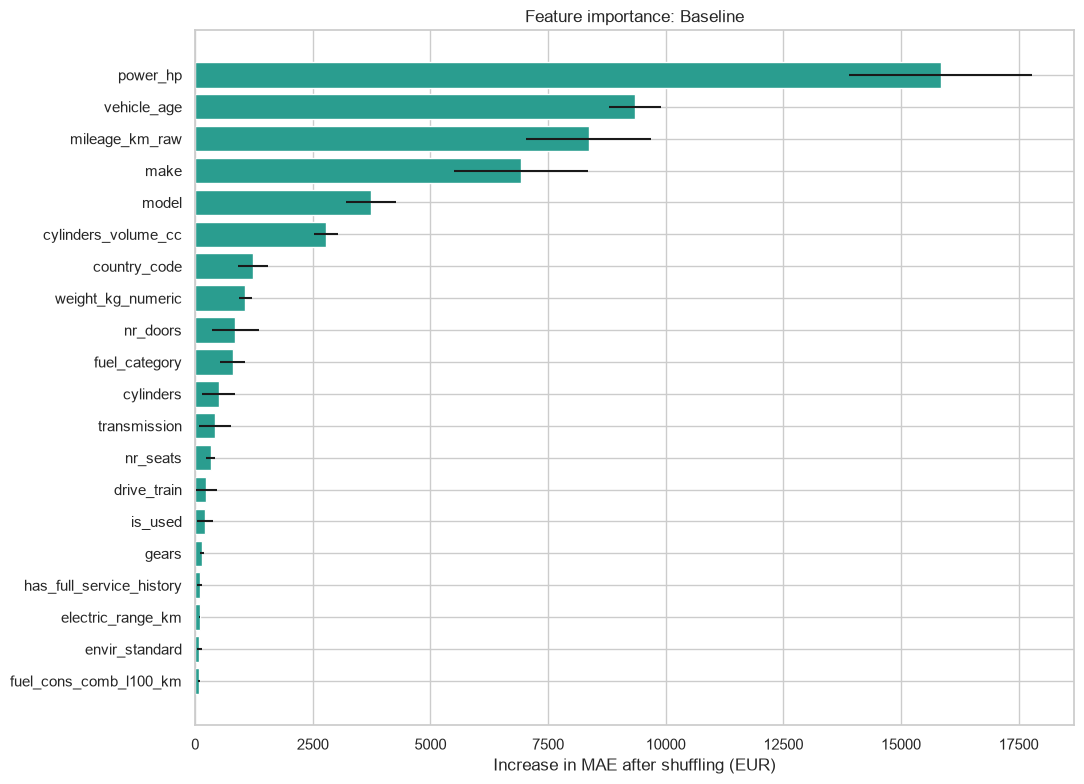

,feature,importance_eur,std_eur
4,power_hp,15844.0,1944.0
1,vehicle_age,9352.0,552.0
0,mileage_km_raw,8368.0,1329.0
13,make,6919.0,1420.0
14,model,3737.0,526.0
7,cylinders_volume_cc,2784.0,251.0
27,country_code,1231.0,315.0
8,weight_kg_numeric,1069.0,131.0
3,nr_doors,850.0,500.0
18,fuel_category,798.0,268.0


In [5]:
sample_index = X_test.sample(min(3_000, len(X_test)), random_state=RANDOM_STATE).index
model_importances = []

for i, (name, model) in enumerate(models.items(), 1):
    print(f"[{i}/3] Permutation importance for {name}", flush=True)
    result = permutation_importance(
        model, X_test.loc[sample_index], y_test.loc[sample_index],
        scoring="neg_mean_absolute_error", n_repeats=3,
        random_state=RANDOM_STATE, n_jobs=1,
    )
    model_importances.append(result.importances)

combined = np.concatenate(model_importances, axis=1)
importance = pd.DataFrame({
    "feature": features,
    "importance_eur": combined.mean(axis=1),
    "std_eur": combined.std(axis=1),
}).sort_values("importance_eur", ascending=False)

top = importance.head(20).sort_values("importance_eur")
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top["feature"], top["importance_eur"],
        xerr=top["std_eur"], color="#2A9D8F")
ax.set(title=f"Feature importance: {selected_name}",
       xlabel="Increase in MAE after shuffling (EUR)", ylabel="")
plt.tight_layout()
plt.show()

display(importance.head(25).round(0))

## 5. What to try next

- Keep engineered features only if they improve cross-validated MAE consistently.
- Extract common trim tokens from `model_version`, such as AMG, M Sport, S line, and GTI.
- Consider country-specific models if country errors remain large and sample sizes are sufficient.
- Add listing date, inflation, tax, and purchasing-power data when available, then use a time split.
- Do not use `price_net`, VAT-derived prices, or other fields calculated from the target price.